In [ ]:
#Edvina Buyuksoy, Shivi Anand
#Project 4
#Data:energy consumption morrocco

In [ ]:
!pip install numpy==1.26.4
!pip install pmdarima

  Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.3 MB)


In [ ]:
import pmdarima as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error

#load and process dataset
power_df = pd.read_csv('powerconsumption.csv')
power_df.info()
power_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


In [ ]:
#Convert to datetime format and set index
power_df['Datetime'] = pd.to_datetime(power_df['Datetime'])
power_df = power_df.set_index('Datetime')

#Resample from 10-minute data to daily
daily_avg = power_df.resample('D').mean()


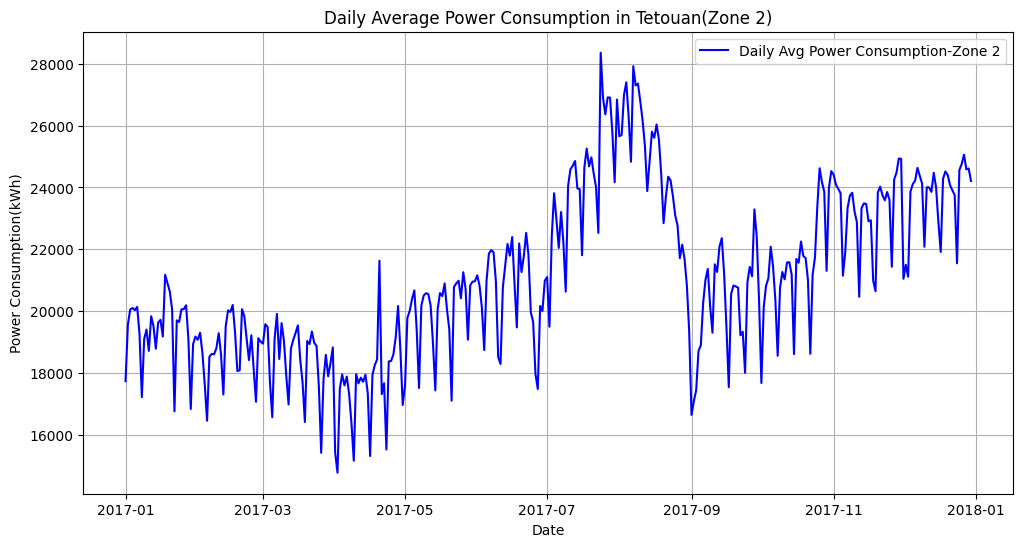

In [ ]:
# original series visualization
plt.figure(figsize=(12, 6))
plt.plot(daily_avg.index, daily_avg['PowerConsumption_Zone2'], label='Daily Avg Power Consumption-Zone 2', color='blue')
plt.xlabel('Date')
plt.ylabel('Power Consumption(kWh)')
plt.title('Daily Average Power Consumption in Tetouan(Zone 2)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#splitting 80%train and 20%test
split = int(len(daily_avg) * 0.8)
train = daily_avg.iloc[:split]
test = daily_avg.iloc[split:]

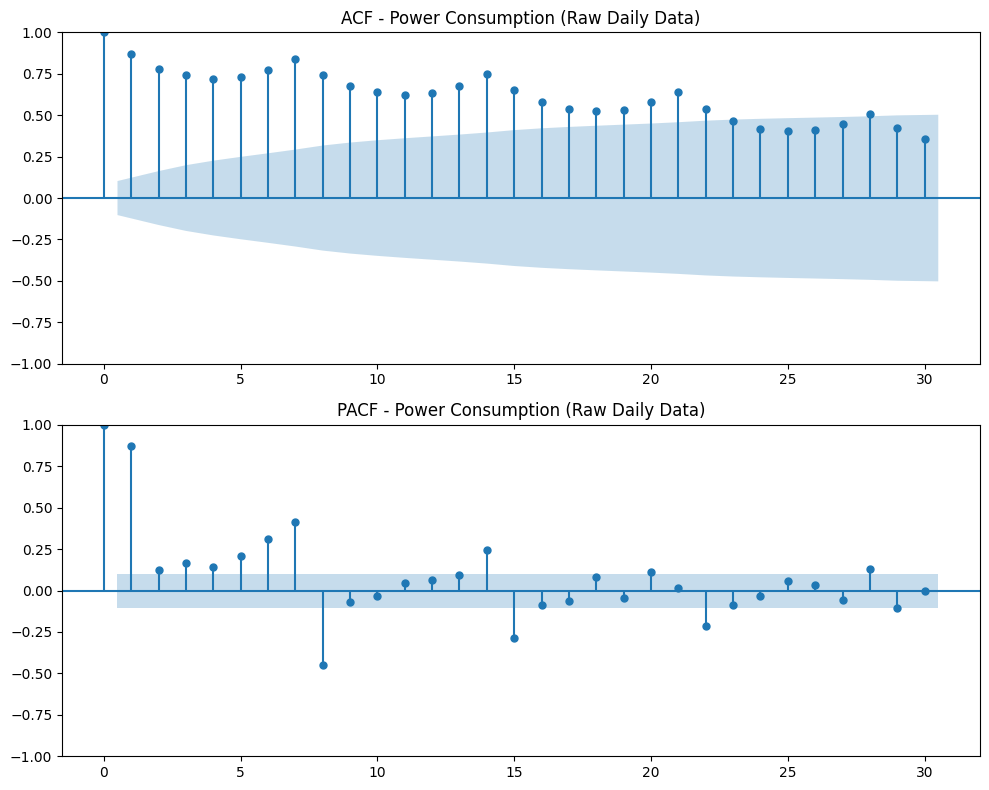

In [ ]:
#acf and pacf, this is exploratory
lag_acf = 30
lag_pacf = 30
height, width = 4, 10

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2 * height))
plot_acf(daily_avg['PowerConsumption_Zone2'], lags=lag_acf, ax=ax[0])
ax[0].set_title('ACF - Power Consumption (Raw Daily Data)')
plot_pacf(daily_avg['PowerConsumption_Zone2'], lags=lag_pacf, ax=ax[1], method='ols')
ax[1].set_title('PACF - Power Consumption (Raw Daily Data)')
plt.tight_layout()
plt.show()

ADF Statistic: -1.525507
p-value: 0.520858
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571
Non-stationary
After First Differencing Stationarity Check
ADF Statistic: -4.879325
p-value: 0.000038
Critical Values:
	1%: -3.449
	5%: -2.870
	10%: -2.571
Stationary


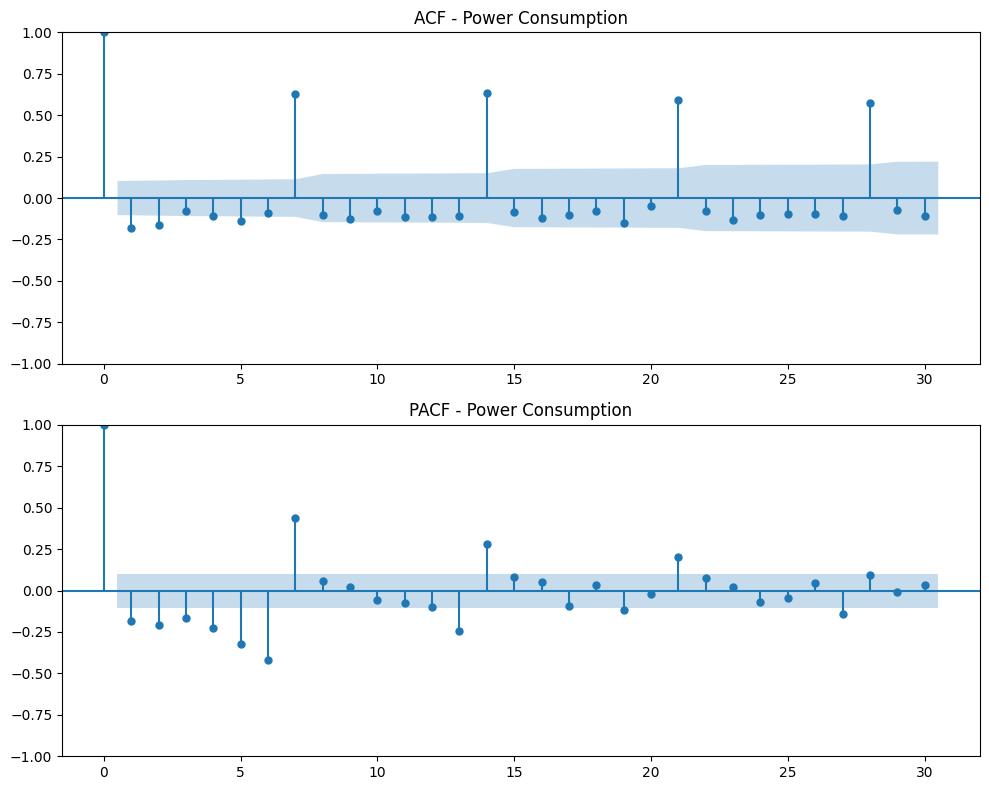

In [ ]:
# Code block from Project 3 for differencing and stationary data:
from statsmodels.tsa.stattools import adfuller
# Function to check if data is stationary (directly copied from in class example code)
def check_stationarity(series):
    result = adfuller(series.values)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))
    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

# running the stationarity function on the data
check_stationarity(daily_avg['PowerConsumption_Zone2'])

# apply first level differencing
power_df = daily_avg['PowerConsumption_Zone2'].diff().dropna()

#checking stationarity after differencing
print("After First Differencing Stationarity Check")
check_stationarity(power_df)

#setting parameters for the acf and pacf visalizations
lag_acf =30
lag_pacf =30
height, width = 4, 10

#plotting pacf for AR and acf for MA
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2 * height))
plot_acf(power_df, lags=lag_acf, ax=ax[0])
ax[0].set_title('ACF - Power Consumption')
plot_pacf(power_df, lags=lag_pacf, ax=ax[1], method='ols')
ax[1].set_title('PACF - Power Consumption')
plt.tight_layout()
plt.show()

In [ ]:
#fit AUTO arima model
#Since our data is daily, and seasonality occurs weekly, set m=7

model = pm.auto_arima(
    train['PowerConsumption_Zone2'],
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    start_P=0, max_P=5,
    seasonal=True,
    m=7,
    d=None, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

#summary
print(model.summary())
print("Order:", model.order)
print("Seasonal order:", model.seasonal_order)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=inf, Time=1.28 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=4961.931, Time=0.03 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=4781.017, Time=0.22 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(5,0,2)(2,1,1)[7] intercept   : AIC=4754.189, Time=5.24 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(4,0,2)(2,1,1)[7] intercept   : AIC=inf, Time=6.09 sec


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(5,0,1)(2,1,1)[7]             : AIC=inf, Time=4.18 sec

Best model:  ARIMA(5,0,1)(2,1,1)[7] intercept
Total fit time: 234.524 seconds
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  291
Model:             SARIMAX(5, 0, 1)x(2, 1, 1, 7)   Log Likelihood               -2359.764
Date:                           Fri, 31 Oct 2025   AIC                           4741.529
Time:                                   18:11:48   BIC                           4781.667
Sample:                               01-01-2017   HQIC                          4757.621
                                    - 10-18-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [ ]:
#forecasting
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


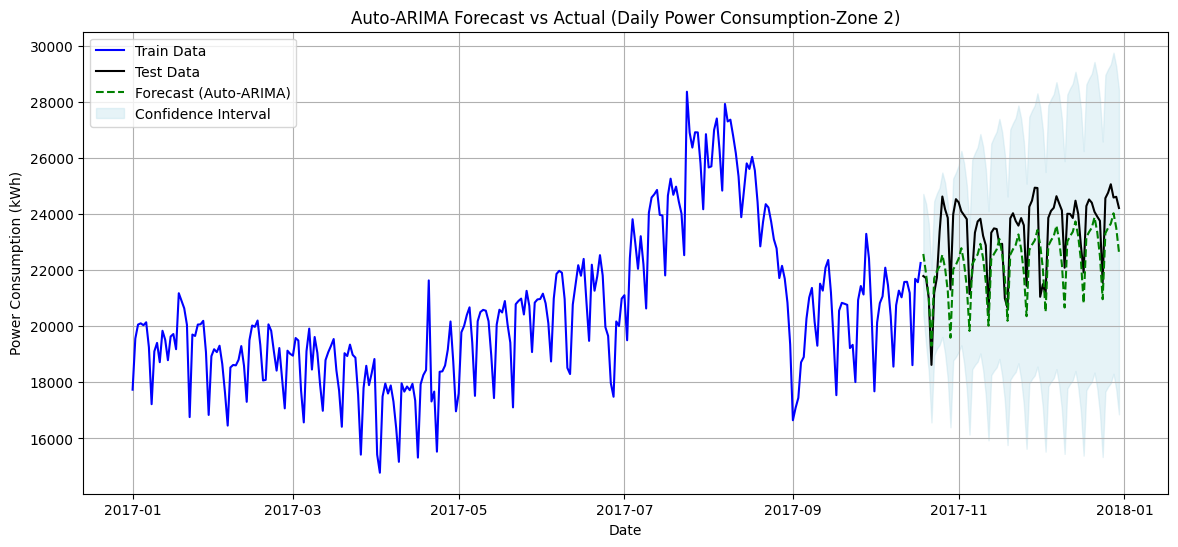

In [ ]:
#visualization
plt.figure(figsize=(14, 6))

# Plot training
plt.plot(train.index, train['PowerConsumption_Zone2'], label='Train Data', color='blue')

# Plot test
plt.plot(test.index, test['PowerConsumption_Zone2'], label='Test Data', color='black')

# Plot forecast, this is the Auto Arima prediction
plt.plot(test.index, forecast, label='Forecast (Auto-ARIMA)', color='green', linestyle='--')

# confidence intervals
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1],
                 color='lightblue', alpha=0.3, label='Confidence Interval')

# Titles and labels
plt.title('Auto-ARIMA Forecast vs Actual (Daily Power Consumption-Zone 2)')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# model accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
#accuracy of our model
mae = mean_absolute_error(test['PowerConsumption_Zone2'], forecast)
rmse = np.sqrt(mean_squared_error(test['PowerConsumption_Zone2'], forecast))
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("Akaike Information Criterion (AIC):", model.aic())

Mean Absolute Error (MAE): 1090.9105849347861
Root Mean Squared Error (RMSE): 1233.1541988878516
Akaike Information Criterion (AIC): 4741.528612069569


In [ ]:
#Performing another autoARIMA with different parameter ranges to explore if we can improve accuracy

In [ ]:
#fit AUTO arima model
#Since our data is daily, and seasonality occurs weekly, set m=7

model = pm.auto_arima(
    train['PowerConsumption_Zone2'],
    seasonal=True, m=7,
    d=1, D=1,
    start_p=1, start_q=1,
    min_p=0,  max_p=3,
    min_q=0,  max_q=3,
    start_P=1, start_Q=1,
    min_P=0,  max_P=2,
    min_Q=0,  max_Q=2,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
    trace=True,
)

#summary
print(model.summary())
print("Order:", model.order)
print("Seasonal order:", model.seasonal_order)

In [ ]:
#forecasting
n_periods = len(test)
forecast, conf_int = model.predict(n_periods=n_periods, return_conf_int=True)


In [ ]:
#visualization
plt.figure(figsize=(14, 6))

# Plot training
plt.plot(train.index, train['PowerConsumption_Zone2'], label='Train Data', color='blue')

# Plot test
plt.plot(test.index, test['PowerConsumption_Zone2'], label='Test Data', color='black')

# Plot forecast, this is the Auto Arima prediction
plt.plot(test.index, forecast, label='Forecast (Auto-ARIMA)', color='green', linestyle='--')

# confidence intervals
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1],
                 color='lightblue', alpha=0.3, label='Confidence Interval')

# Titles and labels
plt.title('Auto-ARIMA Forecast vs Actual (Daily Power Consumption-Zone 2)')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# model accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

#accuracy of our model
mae = mean_absolute_error(test['PowerConsumption_Zone2'], forecast)
rmse = np.sqrt(mean_squared_error(test['PowerConsumption_Zone2'], forecast))
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("Akaike Information Criterion (AIC):", model.aic())

In [ ]:
# Doing a third version using exogenous variables temp and humidity to try to further improve accuracy

In [ ]:
exog_vars = train[['Temperature', 'Humidity']]
exog_vars_test = test[['Temperature', 'Humidity']]

model_v3 = pm.auto_arima(
    train['PowerConsumption_Zone2'],
    exogenous=exog_vars
    seasonal=True, m=7,
    d=0, D=1,
    start_p=1, start_q=1,
    max_p=5, max_q=5,
    start_P=0, max_P=3,
    stepwise=True,
    information_criterion='aic',
    error_action='ignore',
    suppress_warnings=True,
)

In [ ]:
#summary
print(model_v3.summary())
print("Order:", model_v3.order)
print("Seasonal order:", model_v3.seasonal_order)


In [ ]:
#forecasting
n_periods = len(test)
forecast, conf_int = model_v3.predict(n_periods=n_periods, return_conf_int=True)

In [ ]:
#visualization
plt.figure(figsize=(14, 6))

# Plot training
plt.plot(train.index, train['PowerConsumption_Zone2'], label='Train Data', color='blue')

# Plot test
plt.plot(test.index, test['PowerConsumption_Zone2'], label='Test Data', color='black')

# Plot forecast, this is the Auto Arima prediction
plt.plot(test.index, forecast, label='Forecast (Auto-ARIMA)', color='green', linestyle='--')

# confidence intervals
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1],
                 color='lightblue', alpha=0.3, label='Confidence Interval')

# Titles and labels
plt.title('Auto-ARIMA Forecast vs Actual (Daily Power Consumption-Zone 2)')
plt.xlabel('Date')
plt.ylabel('Power Consumption (kWh)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#accuracy of our model
mae = mean_absolute_error(test['PowerConsumption_Zone2'], forecast)
rmse = np.sqrt(mean_squared_error(test['PowerConsumption_Zone2'], forecast))
print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("Akaike Information Criterion (AIC):", model.aic())